# The Heston Stochastic Volatility Model

## Mathematical Formulation

The Heston model extends the Black-Scholes framework by introducing stochastic volatility. It is defined by a system of two correlated stochastic differential equations (SDEs):

### Asset Price Process:
$dS_t = \mu S_t dt + \sqrt{v_t} S_t dW_t^S$

### Variance Process:
$dv_t = \kappa (\theta - v_t) dt + \sigma_v \sqrt{v_t} dW_t^v$

With correlation:
$\text{corr}(dW_t^S, dW_t^v) = \rho dt$

## Transition from Real-World to Risk-Neutral Measures

To transition from the real-world measure ($\mathbb{P}$) to the risk-neutral measure ($\mathbb{Q}$) in the Heston model, we adjust the drifts of both the stock price ($S_t$) and variance ($v_t$) processes to ensure arbitrage-free pricing.

Under $\mathbb{Q}$, the stock drift changes from $\mu$ to $r$ (risk-free rate) 
Volatility still fluctuates, but we add a volatility risk premium (λ) to account for the fact that volatility is risky and untradable.

## Using Girsanov's Thereom to $\mathbb{P} \to \mathbb{Q}$
$\large dW^\mathbb{Q}_{S,t} = dW^\mathbb{P}_{S,t} + \alpha_S dt, \alpha_S  = \frac{\mu_\mathbb{P}-r}{\sqrt{v_t}}$

$\large dW^\mathbb{Q}_{v,t} = dW^\mathbb{P}_{v,t} + \alpha_v dt, \alpha_v  = \frac{\lambda}{\sigma^\mathbb{P}} \sqrt{v_t}$


## Heston's Stochastic Volatility Model under risk-neutral measure

$\large dS_t = r S_t dt + \sqrt{v_t} S_t dW^\mathbb{Q}_{s,t}$

$\large dv_t = \kappa^\mathbb{Q} (\theta^\mathbb{Q} - v_t)dt + \sigma \sqrt{v_t} dW^\mathbb{Q}_{v,t}$

$\large \rho^\mathbb{Q} dt = dW^\mathbb{Q}_{2,t} dW^\mathbb{Q}_{2,t} $

Where: $\large \lambda$ is the variance risk premium

$\large \rho^\mathbb{Q} = \rho, \kappa^\mathbb{Q} = \kappa+\lambda,  \theta^\mathbb{Q} = \kappa \theta/(\kappa+\lambda)$


### Parameter Definitions:
- $S_t$ = Asset price at time $t$
- $v_t$ = Instantaneous variance
- $\mu$ = Expected return (drift)
- $\kappa$ = Mean reversion speed of variance
- $\theta$ = Long-term variance (mean reversion level)
- $\sigma_v$ = Volatility of variance ("vol of vol")
- $\rho$ = Correlation between asset returns and variance changes
- $W_t^S, W_t^v$ = Wiener processes (correlated Brownian motions)



## Discretization for Simulation

Using the Euler-Maruyama scheme, we discretize the SDEs:

### Asset Price Discretization:
$S_{t+\Delta t} = S_t + \mu S_t \Delta t + \sqrt{v_t} S_t \sqrt{\Delta t} Z_1$

### Variance Discretization:
$v_{t+\Delta t} = v_t + \kappa(\theta - v_t)\Delta t + \sigma_v\sqrt{v_t}\sqrt{\Delta t}(\rho Z_1 + \sqrt{1-\rho^2}Z_2)$

Where:
- $Z_1, Z_2$ = Independent standard normal random variables
- $\Delta t$ = Time step size

## Important Properties

### 1. Feller Condition:
$2\kappa\theta > \sigma_v^2$

This condition ensures the variance process remains positive. In practice, it may be violated without causing major issues.

### 2. Variance Mean Reversion:
Expected variance follows:
$\mathbb{E}[v_t] = \theta + (v_0 - \theta)e^{-\kappa t}$

### 3. Variance of Variance:
$\text{Var}[v_t] = \frac{\sigma_v^2}{2\kappa}(1 - e^{-2\kappa t})(v_0 + \kappa\theta)$

## Implementation Considerations

### 1. Numerical Stability:
- Use full truncation scheme for variance:
  $v_{t+\Delta t} = |v_t + \kappa(\theta - \max(v_t,0))\Delta t + \sigma_v\sqrt{\max(v_t,0)}\sqrt{\Delta t}Z|$

### 2. Parameter Constraints:
- $\kappa > 0$ (positive mean reversion)
- $\theta > 0$ (positive long-term variance)
- $\sigma_v > 0$ (positive vol of vol)
- $-1 \leq \rho \leq 1$ (correlation bounds)
- $v_0 > 0$ (positive initial variance)

### 3. Monte Carlo Error Analysis:

Standard Error of Price Estimate:
$SE = \frac{\sigma_{MC}}{\sqrt{N}}$

Where:
$\sigma_{MC} = \sqrt{\frac{1}{N-1}\sum_{i=1}^N (P_i - \bar{P})^2}$

- $P_i$ = Price from $i$-th simulation
- $\bar{P}$ = Mean simulated price
- $N$ = Number of simulations



In [4]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

In [5]:
class HestonUsingMCS:
    def __init__(self, S0, v0, rho, kappa, theta, sigma, T, N, M, r, K):
        """
        Parameters for the Heston model and simulation.
        S0: Initial stock price
        v0: Initial variance
        rho: Correlation between asset returns and variance
        kappa: Rate of mean reversion for variance
        theta: Long-term mean of variance
        sigma: Volatility of volatility
        T: Time to maturity
        N: Number of time steps
        M: Number of simulations
        r: Risk-free rate
        K: Strike price
        """
        self.S0 = S0
        self.v0 = v0
        self.rho = rho
        self.kappa = kappa
        self.theta = theta
        self.sigma = sigma
        self.T = T
        self.N = N
        self.M = M
        self.r = r
        self.K = K
        self.dt = T / N
        self.S_paths = None  # To store simulated stock paths
        self.v_paths = None  # To store simulated variance paths
    def simulate_paths(self):
        """
        Simulate M paths of stock prices and variances using the Heston model.
        Stores paths in self.S_paths and self.v_paths.
        Returns terminal stock prices.
        """
        dt = self.dt
        # Correlated Brownian motions setup
        mu = np.array([0, 0])
        cov = np.array([[1, self.rho], [self.rho, 1]])

        # Initialize paths
        S = np.full((self.N + 1, self.M), self.S0)
        v = np.full((self.N + 1, self.M), self.v0)

        # Generate random numbers for all steps
        Z = np.random.multivariate_normal(mu, cov, (self.N, self.M))

        for i in range(1, self.N + 1):
            S_prev = S[i-1, :]
            v_prev = v[i-1, :]

            # Brownian increments for stock and variance
            Z_S = Z[i-1, :, 0]
            Z_v = Z[i-1, :, 1]

            # Update stock price (exact scheme for log)
            S[i, :] = S_prev * np.exp((self.r - 0.5 * v_prev) * dt + np.sqrt(v_prev * dt) * Z_S)
            
            # Update variance with full truncation to avoid negative values
            v_new = v_prev + self.kappa * (self.theta - v_prev) * dt + self.sigma * np.sqrt(v_prev * dt) * Z_v
            v[i, :] = np.maximum(v_new, 0)

        self.S_paths = S
        self.v_paths = v
        return S,v

    def price_call(self):
        """Calculate call option price and standard error using simulated paths."""
        ST = self.simulate_paths()[0]
        payoff = np.maximum(ST - self.K, 0)
        discount = np.exp(-self.r * self.T)
        price = discount * np.mean(payoff)
        stderr = discount * np.std(payoff, ddof=1) / np.sqrt(self.M)
        return price, stderr

    def price_put(self):
        """Calculate put option price and standard error using simulated paths."""
        ST = self.simulate_paths()
        payoff = np.maximum(self.K - ST, 0)
        discount = np.exp(-self.r * self.T)
        price = discount * np.mean(payoff)
        stderr = discount * np.std(payoff, ddof=1) / np.sqrt(self.M)
        return price, stderr

In [6]:
# Example parameters
S0 = 100.0   # Initial stock price
v0 = 0.04    # Initial variance (e.g., 0.04 for 20% volatility)
kappa = 1.0  # Mean reversion speed
theta = 0.04 # Long-term variance
sigma = 0.2  # Volatility of volatility
rho = -0.7   # Correlation
T = 1.0      # Time to maturity
N = 100      # Time steps
M = 10000    # Simulations
r = 0.05     # Risk-free rate
K = 104      # Strike price

# Create Heston model instance
heston_model = HestonUsingMCS(S0, v0, 0.98, kappa, theta, sigma, T, N, M, r, K)

In [7]:
s,v=heston_model.simulate_paths()


In [8]:
call, call_stderr = heston_model.price_call()
print(call,call_stderr)
put, put_stderr = heston_model.price_call()
print(put ,put_stderr)

4.734598897036199 0.11006431247157619
4.584490075457233 0.10896296197253888


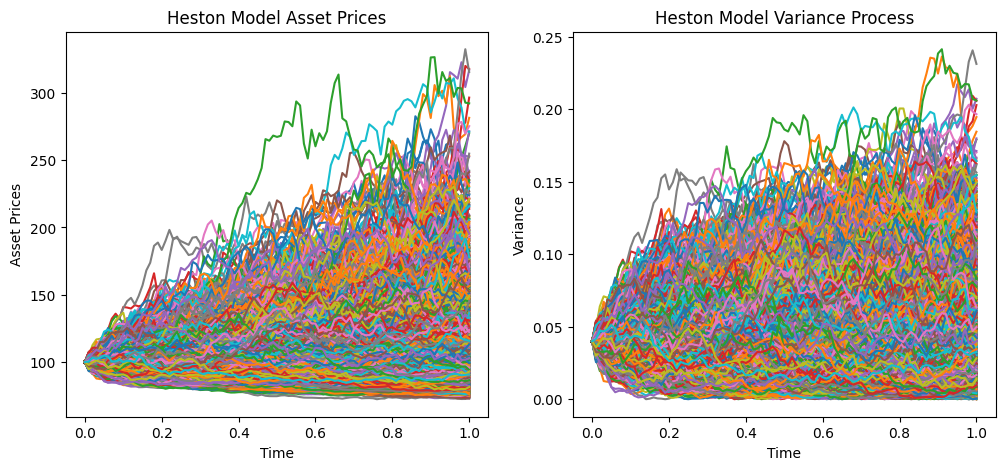

In [9]:
fig, (ax1, ax2)  = plt.subplots(1, 2, figsize=(12,5))
time = np.linspace(0,T,N+1)
ax1.plot(time,s)
ax1.set_title('Heston Model Asset Prices')
ax1.set_xlabel('Time')
ax1.set_ylabel('Asset Prices')

ax2.plot(time,v)
ax2.set_title('Heston Model Variance Process')
ax2.set_xlabel('Time')
ax2.set_ylabel('Variance')

plt.show()

In [10]:
# simulate gbm process at time T
gbm = S0*np.exp( (r - theta**2/2)*T + np.sqrt(theta)*np.sqrt(T)*np.random.normal(0,1,M) )

NameError: name 'S_p' is not defined

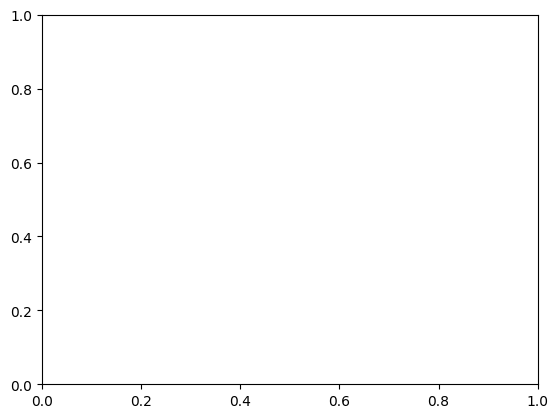

In [11]:
fig, ax = plt.subplots()
import seaborn as sns
ax = sns.kdeplot(S_p[-1], label=r"$\rho= 0.98$", ax=ax)
ax = sns.kdeplot(S_n[-1], label=r"$\rho= -0.98$", ax=ax)
ax = sns.kdeplot(gbm, label="GBM", ax=ax)

plt.title(r'Asset Price Density under Heston Model')
plt.xlim([20, 180])
plt.xlabel('$S_T$')
plt.ylabel('Density')
plt.legend()
plt.show()


In [12]:
rho = -0.7
S,v = heston_model_sim(S0, v0, rho, kappa, theta, sigma,T, N, M)


NameError: name 'heston_model_sim' is not defined

In [18]:
!pip install py_vollib_vectorized

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.6/74.6 kB 1.2 MB/s eta 0:00:00a 0:00:01
  Created wheel for py-vollib: filename=py_vollib-1.0.1-py3-none-any.whl size=62829 sha256=39dfeea1ac38898d9a78445added3802f1973cbffad0ed9030d6a13afa994d63
  Stored in directory: /Users/utsavsharma/Library/Caches/pip/wheels/c0/5c/8f/1ed590a10a2cca3cbfa7a7caa29fb5d729b3e1f819bfda4b5e
  Created wheel for py-lets-be-rational: filename=py_lets_be_rational-1.0.1-py3-none-any.whl size=24452 sha256=e968e80ea6f5c6f09b6e1833d0ba82278eb1a8a8bcc1458e4aa419aa15d1a29a
  Stored in directory: /Users/utsavsharma/Library/Caches/pip/wheels/d9/20/b1/018f644bacb669d5cd6af600fe09ee0729ae5d75875a9f3043
Successfully built py-vollib py-lets-be-rational


In [19]:
# Set strikes and complete MC option price for different strikes
K = np.arange(20,180,2)

puts = np.array([np.exp(-r*T)*np.mean(np.maximum(k-S,0)) for k in K])
calls = np.array([np.exp(-r*T)*np.mean(np.maximum(S-k,0)) for k in K])
from py_vollib_vectorized import vectorized_implied_volatility as implied_vol

put_ivs = implied_vol(puts, S0, K, T, r, flag='p', q=0, return_as='numpy', on_error='ignore')
call_ivs = implied_vol(calls, S0, K, T, r, flag='c', q=0, return_as='numpy')

/opt/anaconda3/lib/python3.11/site-packages/py_vollib_vectorized/implied_volatility.py:75: UserWarning: Found Below Intrinsic contracts at index [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34]
  below_intrinsic, above_max_price = _check_below_and_above_intrinsic(K, F, flag, undiscounted_option_price, on_error)


In [3]:
plt.plot(K, call_ivs, label=r'IV calls')
plt.plot(K, put_ivs, label=r'IV puts')

plt.ylabel('Implied Volatility')
plt.xlabel('Strike')

plt.title('Implied Volatility Smile from Heston Model')
plt.legend()
plt.show()

NameError: name 'plt' is not defined

Using standard arbitrage arguments we arrive at Garman's partial differential equation:

$\large \frac{\partial C}{\partial t} + \frac{S^2 v}{2}\frac{\partial^2 C}{\partial S^2} + rS\frac{\partial C}{\partial S} - rC + [\kappa(\theta-v)-\lambda v]\frac{\partial C}{\partial v} + \frac{\sigma^2 v}{2}\frac{\partial^2 C}{\partial v^2} + \rho \sigma Sv \frac{\partial^2 C}{\partial S \partial v} = 0$

Heston builds the solution of the PDE above by the method of characteristic functions. He looks for a solution of the form corresponding to the Black-Scholes model:

$\large C(S_0, K, v_0, \tau) = SP_1 - Ke^{-r\tau} P_2$

where:
- $P_1$ is the delta of the European call option
- $P_2$ is the conditional risk neutral probability that the asset price will be greater than K at the maturity

Both probabilities $P_{1,2}$ also satisfy the PDE provided that characteristic functions $\varphi_1$, $\varphi_2$ are known. The terms $P_{1,2}$ are defined via the inverse Fourier transformation:

$\large X = \ln(S)$

$\large P_j = \frac{1}{2} + \frac{1}{\pi}\int_{0}^{\infty} \Re\left[\frac{e^{-i\phi \ln K}\varphi_j(X_0,K,v_0,\tau;\phi)}{i\phi}\right]d\phi, j \in \{1,2\}$

Heston assumes the characteristic functions $\varphi_1$, $\varphi_2$ having the form:

$\large \varphi_j(X_0, K, v_0,\tau; \phi) = e^{C(\tau;\phi)+D(\tau;\phi)v+i\phi X}$

With semianalytical solution:

$\large C(\tau;\phi) = r\phi i \tau + \frac{a}{\sigma^2}[(b_j -\rho\sigma \phi i + d)\tau - 2\ln[\frac{1-ge^{d\tau}}{1-g}]]$

$\large D(\tau;\phi) = \frac{b_j -\rho\sigma \phi i + d}{\sigma^2}\left[\frac{1-e^{d\tau}}{1-ge^{d\tau}}\right]$

where:
- $\large g = \frac{b_j -\rho\sigma \phi i + d}{b_j -\rho\sigma \phi i - d}$
- $\large d = \sqrt{(\rho\sigma \phi i -b_j)^2 - \sigma^2 (2u_j\phi i - \phi^2)}$
- $\large u_1 = 0.5, u_2 = -0.5$
- $\large a = \kappa \theta$
- $\large b_1 = \kappa + \lambda - \rho \sigma$
- $\large b_2 = \kappa + \lambda$

Let's obtain a simplified formula with 1 integral

$\large C(S_0, K, v_0, \tau) = S_0[\frac{1}{2} + \frac{1}{\pi}\int_{0}^{\infty} \Re\left[\frac{e^{-i\phi \ln K}\varphi_1(X_0, K, v_0,\tau;\phi)}{i\phi}\right]d\phi] - Ke^{-r\tau}[\frac{1}{2} + \frac{1}{\pi}\int_{0}^{\infty} \Re\left[\frac{e^{-i\phi \ln K}\varphi_2(X_0, K, v_0,\tau;\phi)}{i\phi}\right]d\phi]$

$\large C(S_0, K, v_0, \tau) = \frac{1}{2}(S_0 - Ke^{-r\tau}) + \frac{1}{\pi}\int_{0}^{\infty} \Re\left[\frac{S_0\varphi_1(\phi)}{i\phi K^{i\phi}} - Ke^{-r\tau}\frac{\varphi_2(\phi)}{i\phi K^{i\phi}}\right]d\phi$

## Let's rearrange $\large \varphi$ & simplify solution to 1 integral

$\large C(S_0, K, v_0, \tau) = \frac{1}{2}(S_0 - Ke^{-r\tau}) + \frac{1}{\pi}\int_{0}^{\infty} \Re\left[e^{r\tau}\frac{\varphi(\phi-i)}{i\phi K^{i\phi}} - K\frac{\varphi(\phi)}{i\phi K^{i\phi}}\right]d\phi$


## Understanding the change in $\varphi$ terms under combined integral
$\large \varphi(X_0, K, v_0,\tau; \phi) = e^{r \phi i \tau} S^{i \phi}[\frac{1-ge^{d\tau}}{1-g}]^{\frac{-2a}{\sigma^2}} exp[\frac{a \tau}{\sigma^2} (b_2 -\rho\sigma \phi i + d) + \frac{v_0}{\sigma^2}(b_2 -\rho\sigma \phi i + d)[\frac{1-e^{d\tau}}{1-ge^{d\tau}}]]$

where d and g no longer change with b1, b2 or u1, u2
- $\large d = \sqrt{(\rho\sigma \phi i - b)^2 + \sigma^2 (\phi i + \phi^2)}$
- $\large g = \frac{b -\rho\sigma \phi i + d}{b -\rho\sigma \phi i - d}$
- $\large a = \kappa \theta$
- $\large b = \kappa + \lambda$

## Understanding the change in d and g terms under combined integral

$\large \varphi_j(X_0, K, v_0,\tau; \phi) = e^{C(\tau;\phi)+D(\tau;\phi)v+i\phi X}$

remember $X = ln(S)$ therefore, $\large e^{i \phi X} = e^{ln(S^{i \phi})} = S^{i \phi}$

$\large C(\tau;\phi) = r\phi i \tau + \frac{a}{\sigma^2}[(b_j -\rho\sigma \phi i + d)\tau - 2ln[\frac{1-ge^{d\tau}}{1-g}])]$

$\large e^{C(\tau;\phi)} = e^{r\phi i \tau} exp[\frac{a}{\sigma^2}(b_j -\rho\sigma \phi i + d)\tau] e^{ln[\frac{1-ge^{d\tau}}{1-g}]^{\frac{-2a}{\sigma^2}})} = e^{r \phi i \tau} [\frac{1-ge^{d\tau}}{1-g}]^{\frac{-2a}{\sigma^2}} exp[\frac{a \tau}{\sigma^2} (b_j -\rho\sigma \phi i + d)]$

$\large D(\tau;\phi) = \frac{b_j -\rho\sigma \phi i + d}{\sigma^2}[\frac{1-e^{d\tau}}{1-ge^{d\tau}}]$

Now let's take a look at $d_j$ and $g_j$ and how they changed with b1,b2 and u1,u2

- $\large d_j = \sqrt{(\rho\sigma \phi i -b_j)^2 - \sigma^2 (2u_j\phi i - \phi^2)}$
- $\large g_j = \frac{b_j -\rho\sigma \phi i + d}{b_j -\rho\sigma \phi i - d}$

For both $d_j$ and $g_j$ how can we reconcile the difference between b1 and b2 calculation. Well this is taken into account by the offset of $\varphi(\phi-i)$ compared to $\varphi(\phi)$. How can this be?

### Understanding change in $b_j$ term to $b$ under combined integral
Let's take a look at the first term of d (within squared brackets -frist squared term) to understand this $\rho\sigma \phi i - b$. When I substitute $\Phi=\phi-i$ into the function $\varphi(\Phi)$
- $\large \rho \sigma (\phi-i) i - b = \rho \sigma (\phi i -i*i) - (\kappa + \lambda) = \rho \sigma (\phi i + 1) - (\kappa + \lambda) = \rho \sigma \phi i - (\kappa + \lambda - \rho \sigma) = \rho \sigma \phi i - b_1$

- $\large \rho \sigma (\phi) i - b) = \rho \sigma \phi i - (\kappa + \lambda) = \rho \sigma \phi i - (\kappa + \lambda ) = \rho \sigma \phi i - b_2$

### Understanding change in $u_j$ term under combined integral
Let's take a look at the second term of d (within squared brackets -second squared term) to understand this $+ \sigma^2 (\phi i + \phi^2)$. When I substitute $\Phi=\phi-i$ into the function $\varphi(\Phi)$

- $\large + \sigma^2 (\phi i + \phi^2) = \sigma^2 ((\phi-i) i + (\phi-i)^2) = \sigma^2 ( \phi i+ 1 + \phi^2-2si-1 ) = \sigma^2 (-\phi i + \phi^2) = - \sigma^2 (2 u_1 \phi i - \phi^2) = - \sigma^2 (2 * 0.5 * \phi i - \phi^2)$

- $\large + \sigma^2 (\phi i + \phi^2) = - \sigma^2 (2 u_2 \phi i - \phi^2) = - \sigma^2 (2 * - 0.5 * \phi i - \phi^2)$

## Part 1 - implement the characteristic function

$\large \varphi(X_0, K, v_0,\tau; \phi) = e^{r \phi i \tau} S^{i \phi}\left[\frac{1-ge^{d\tau}}{1-g}\right]^{\frac{-2a}{\sigma^2}} \exp\left[\frac{a \tau}{\sigma^2} (b_2 -\rho\sigma \phi i + d) + \frac{v_0}{\sigma^2}(b_2 -\rho\sigma \phi i + d)\left[\frac{1-e^{d\tau}}{1-ge^{d\tau}}\right]\right]$

where d and g no longer change with $b_1$, $b_2$ or $u_1$, $u_2$:
- $\large d = \sqrt{(\rho\sigma \phi i - b)^2 + \sigma^2 (\phi i + \phi^2)}$
- $\large g = \frac{b -\rho\sigma \phi i + d}{b -\rho\sigma \phi i - d}$
- $\large a = \kappa \theta$
- $\large b = \kappa + \lambda$

## Part 2 - define the integrand as a function

$\large \int_{0}^{\infty} \Re\left[e^{r\tau}\frac{\varphi(\phi-i)}{i\phi K^{i\phi}} - K\frac{\varphi(\phi)}{i\phi K^{i\phi}}\right]d\phi$

## Part 3 - perform numerical integration over integrand and calculate option price

$\large C(S_0, K, v_0, \tau) = \frac{1}{2}(S_0 - Ke^{-r\tau}) + \frac{1}{\pi}\int_{0}^{\infty} \Re\left[e^{r\tau}\frac{\varphi(\phi-i)}{i\phi K^{i\phi}} - K\frac{\varphi(\phi)}{i\phi K^{i\phi}}\right]d\phi$

### Using rectangular integration

## Parameters to determine via calibration with market prices

$\Large \Theta = (v_0, \kappa, \theta, \sigma, \rho, \lambda)$

Minimize squared error:

$\Large \text{SqErr}(\Theta) = \sum^N_{i=1}\sum^M_{j=1}w_{ij}(C_{\text{MP}}(X_i,\tau_j) - C_{\text{SV}}(S_\tau, X_i,\tau_j,r_j,\Theta))^2 + \text{Penalty}(\Theta, \Theta_0)$

- The penalty function may be e.g. the distance to the initial parameter vector $\text{Penalty}(\Theta, \Theta_0) = \|\Theta - \Theta_0\|^2$

## Calibration - Optimization Objective function

$\Large \hat{\Theta} = \underset{\Theta \in U_\Theta}{\text{arg min}} \ \text{SqErr}(\Theta)$

Here we assume that the set of possible combinations of parameters $U_\Theta$ is compact and in the range for which a solution exists.
## Calibration Methods

### 1. Maximum Likelihood:
Log-likelihood function:
$\mathcal{L}(\theta) = -\frac{1}{2}\sum_{i=1}^n \left(\ln(2\pi v_i) + \frac{(r_i - \mu\Delta t)^2}{v_i\Delta t}\right)$

### 2. Root Mean Square Error:
$RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^n (C_i^{market} - C_i^{model})^2}$

Where:
- $C_i^{market}$ = Market option price
- $C_i^{model}$ = Model option price

## Applications

1. **Option Pricing**:
   - European options
   - Path-dependent options
   - Forward-start options

2. **Risk Management**:
   - VaR calculations
   - Stress testing
   - Scenario analysis

3. **Trading Strategies**:
   - Volatility trading
   - Delta-neutral strategies
   - Correlation trading

## Parameters Selection Guidelines

Typical ranges for parameters:
- $\kappa$: [1.0, 5.0]
- $\theta$: [0.01, 0.04]
- $\sigma_v$: [0.1, 1.0]
- $\rho$: [-0.9, -0.3]
- $v_0$: [0.01, 0.05]

In [41]:
import numpy as np
from scipy.integrate import quad

class HestonModel:
    def __init__(self, S0, K, v0, kappa, theta, sigma, rho, lambd, tau, r):
        """
        Heston model parameters:
        S0: Initial stock price
        K: Strike price
        v0: Initial variance
        kappa: Rate of mean reversion for variance
        theta: Long-term variance
        sigma: Volatility of variance
        rho: Correlation between stock and variance
        lambd: Risk premium
        tau: Time to maturity
        r: Risk-free rate
        """
        self.S0 = S0
        self.K = K
        self.v0 = v0
        self.kappa = kappa
        self.theta = theta
        self.sigma = sigma
        self.rho = rho
        self.lambd = lambd
        self.tau = tau
        self.r = r
    
    def heston_charfunc(self, phi):
        """Computes the characteristic function of the Heston model."""
        a = self.kappa * self.theta
        b = self.kappa + self.lambd
        rspi = self.rho * self.sigma * phi * 1j
        d = np.sqrt((rspi - b) ** 2 + (phi * 1j + phi ** 2) * self.sigma ** 2)
        g = (b - rspi + d) / (b - rspi - d)
        
        exp1 = np.exp(self.r * phi * 1j * self.tau)
        term2 = self.S0 ** (phi * 1j) * ((1 - g * np.exp(d * self.tau)) / (1 - g)) ** (-2 * a / self.sigma ** 2)
        exp2 = np.exp(a * self.tau * (b - rspi + d) / self.sigma ** 2 + \
                      self.v0 * (b - rspi + d) * ((1 - np.exp(d * self.tau)) / (1 - g * np.exp(d * self.tau))) / self.sigma ** 2)
        
        return exp1 * term2 * exp2
    
    def integrand(self, phi):
        """Defines the integrand function for the Heston model price calculation."""
        numerator = np.exp(self.r * self.tau) * self.heston_charfunc(phi - 1j) - self.K * self.heston_charfunc(phi)
        denominator = 1j * phi * self.K ** (1j * phi)
        return numerator / denominator
    
    def heston_price(self, option_type="call"):
        """Computes the price of a European call or put option using the Heston model."""
        real_integral, err = np.real(quad(self.integrand, 0, 100))
        call_price = (self.S0 - self.K * np.exp(-self.r * self.tau)) / 2 + real_integral / np.pi
        if option_type.lower() == "call":
            return call_price
        elif option_type.lower() == "put":
            return call_price + self.K * np.exp(-self.r * self.tau) - self.S0
        else:
            raise ValueError("Invalid option type. Choose 'call' or 'put'.")


In [42]:
# Parameters to test model

S0 = 100. # initial asset price
K = 100. # strike
v0 = 0.1 # initial variance
r = 0.03 # risk free rate
kappa = 1.5768 # rate of mean reversion of variance process
theta = 0.0398 # long-term mean variance
sigma = 0.3 # volatility of volatility
lambd = 0.575 # risk premium of variance
rho = -0.5711 # correlation between variance and stock process
tau = 1. # time to maturity

In [43]:
heston=HestonModel(S0, K, v0, kappa, theta, sigma, rho, lambd, tau, r)

In [46]:
heston.heston_price()

11.54036181935536

In [47]:
import requests
import pandas as pd
import numpy as np
from scipy.optimize import minimize
from datetime import datetime as dt

# Fetch Nifty Option Chain Data
url = "https://www.nseindia.com/api/option-chain-indices?symbol=NIFTY"

# Headers to simulate a browser request
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/85.0.4183.121 Safari/537.36",
    "Accept-Language": "en-US,en;q=0.9",
    "Accept-Encoding": "gzip, deflate, br"
}

# Fetch data from NSE API
session = requests.Session()
session.get("https://www.nseindia.com", headers=headers)  # First visit to set cookies
response = session.get(url, headers=headers)
data = response.json()  # Parse JSON data

# User-defined expiry date
TARGET_EXPIRY = '27-Feb-2025'  # Change as needed

# Parse data for call options
options_data = []
S0 = data['records']['underlyingValue']  # Current NIFTY price


In [60]:
options_data_call = []
options_data_put = []

for record in data['records']['data']:
    expiry_date = record['expiryDate']
    if expiry_date == TARGET_EXPIRY:
        strike_price = record['strikePrice']

        # Call options (CE)
        bid_ce = record.get('CE', {}).get('bidprice', None)
        ask_ce = record.get('CE', {}).get('askPrice', None)
        iv_ce = record.get('CE', {}).get('impliedVolatility', None)
        if bid_ce and ask_ce:
            mid_price_ce = (bid_ce + ask_ce) / 2
            options_data_call.append({'expiry_date': expiry_date, 'strike': strike_price, 'price': mid_price_ce, 'iv': iv_ce})

        # Put options (PE)
        bid_pe = record.get('PE', {}).get('bidprice', None)
        ask_pe = record.get('PE', {}).get('askPrice', None)
        iv_pe = record.get('PE', {}).get('impliedVolatility', None)
        if bid_pe and ask_pe:
            mid_price_pe = (bid_pe + ask_pe) / 2
            options_data_put.append({'expiry_date': expiry_date, 'strike': strike_price, 'price': mid_price_pe, 'iv': iv_pe})

# Convert to DataFrame
df_call = pd.DataFrame(options_data_call)
df_put = pd.DataFrame(options_data_put)
if df_call.empty or df_put.empty:
    raise ValueError("No options data found for the specified expiry date.")

df_put

,expiry_date,strike,price,iv
0,27-Feb-2025,21100,6.775,19.93
1,27-Feb-2025,21150,8.250,19.79
2,27-Feb-2025,21200,8.075,19.62
3,27-Feb-2025,21250,7.925,19.27
4,27-Feb-2025,21300,8.800,19.15
...,...,...,...,...
104,27-Feb-2025,26300,2924.250,0.00
105,27-Feb-2025,26350,2926.125,0.00
106,27-Feb-2025,26400,3024.750,0.00
107,27-Feb-2025,26450,3023.475,0.00


In [66]:
df_call['maturity'] = df_call['expiry_date'].apply(
    lambda x: (dt.strptime(x, '%d-%b-%Y') - dt.strptime(data['records']['timestamp'], '%d-%b-%Y %H:%M:%S')).days / 365
)
df_put['maturity'] = df_put['expiry_date'].apply(
    lambda x: (dt.strptime(x, '%d-%b-%Y') - dt.strptime(data['records']['timestamp'], '%d-%b-%Y %H:%M:%S')).days / 365
)
def curve_fit(maturity):
    return 0.06857  # Assuming 5% constant risk-free rate for simplicity

df_call['rate'] = df_call['maturity'].apply(curve_fit)
df_put['rate'] = df_put['maturity'].apply(curve_fit)

# Extract arrays for calibration
K_call = df_call['strike'].values   # Strike prices for calls
P_call = df_call['price'].values    # Market prices for calls
tau_call = df_call['maturity'].values    # Time to maturity for calls
r_call = df_call['rate'].values        # Risk-free rates for calls

# Put options market data
K_put = df_put['strike'].values     # Strike prices for puts
P_put = df_put['price'].values      # Market prices for puts
tau_put = df_put['maturity'].values      # Time to maturity for puts
r_put = df_put['rate'].values          # Risk-free rates for puts




In [68]:
def SqErr_call(x):
    v0, kappa, theta, sigma, rho, lambd = x
    heston_prices = []
    for K, tau, r in zip(K_call, tau_call, r_call):
        heston_model = HestonModel(S0, K, v0, kappa, theta, sigma, rho, lambd, tau, r)
        price = heston_model.heston_price("call")
        heston_prices.append(price.real)  # Ensure real numbers
    err = np.sum((P_call - np.array(heston_prices))**2) / len(P_call)
    return err

def SqErr_put(x):
    v0, kappa, theta, sigma, rho, lambd = x
    heston_prices = []
    for K, tau, r in zip(K_put, tau_put, r_put):
        heston_model = HestonModel(S0, K, v0, kappa, theta, sigma, rho, lambd, tau, r)
        price = heston_model.heston_price("put")
        heston_prices.append(price.real)  # Ensure real numbers
    err = np.sum((P_put - np.array(heston_prices))**2) / len(P_put)
    return err

# Initial parameter guesses and bounds
params = {
    "v0": {"x0": 0.1, "lbub": [1e-3, 0.1]},
    "kappa": {"x0": 3, "lbub": [1e-3, 5]},
    "theta": {"x0": 0.05, "lbub": [1e-3, 0.1]},
    "sigma": {"x0": 0.3, "lbub": [1e-2, 1]},
    "rho": {"x0": -0.8, "lbub": [-1, 0]},
    "lambd": {"x0": 0.03, "lbub": [-1, 1]},
}

x0 = [param["x0"] for param in params.values()]
bnds = [param["lbub"] for param in params.values()]

# Optimize separately
result_call = minimize(SqErr_call, x0, method='L-BFGS-B', bounds=bnds, options={'maxiter': 5000, 'disp': True})
result_put = minimize(SqErr_put, x0, method='L-BFGS-B', bounds=bnds, options={'maxiter': 5000, 'disp': True})

# Output results
calibrated_params_call = dict(zip(params.keys(), result_call.x))
calibrated_params_put = dict(zip(params.keys(), result_put.x))

print("Heston Model Calibrated Parameters for Calls:", calibrated_params_call)
print("Heston Model Calibrated Parameters for Puts:", calibrated_params_put)


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            6     M =           10

At X0         1 variables are exactly at the bounds

At iterate    0    f=  7.42873D+04    |proj g|=  2.00000D+00

At iterate    1    f=  1.89313D+04    |proj g|=  1.05419D+00

At iterate    2    f=  8.14602D+03    |proj g|=  7.13603D-01

At iterate    3    f=  5.25183D+03    |proj g|=  4.73808D+00

At iterate    4    f=  4.47610D+03    |proj g|=  8.40900D-01

At iterate    5    f=  4.40984D+03    |proj g|=  8.54139D-01

At iterate    6    f=  4.40333D+03    |proj g|=  8.59342D-01

At iterate    7    f=  4.39189D+03    |proj g|=  1.83335D+00

At iterate    8    f=  4.35313D+03    |proj g|=  1.88534D+00

At iterate    9    f=  4.28814D+03    |proj g|=  4.99900D+00

At iterate   10    f=  4.24292D+03    |proj g|=  3.91028D+00

At iterate   11    f=  4.15704D+03    |proj g|=  9.89660D-01

At iterate   12    f=  4.15636D+03    |proj g|=  9.89304D-01

At iterate   13    f=  4.1

/var/folders/y3/nzngm7d50bs8pgqzzcqgkwzh0000gn/T/ipykernel_7028/1246206343.py:40: RuntimeWarning: overflow encountered in exp
  exp2 = np.exp(a * self.tau * (b - rspi + d) / self.sigma ** 2 + \
/var/folders/y3/nzngm7d50bs8pgqzzcqgkwzh0000gn/T/ipykernel_7028/1246206343.py:43: RuntimeWarning: invalid value encountered in scalar multiply
  return exp1 * term2 * exp2
/var/folders/y3/nzngm7d50bs8pgqzzcqgkwzh0000gn/T/ipykernel_7028/1246206343.py:53: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  real_integral, err = np.real(quad(self.integrand, 0, 100))



At iterate   18    f=  3.95012D+03    |proj g|=  4.36933D+00



 Bad direction in the line search;
   refresh the lbfgs memory and restart the iteration.



At iterate   19    f=  3.93710D+03    |proj g|=  1.70473D+00

At iterate   20    f=  3.93651D+03    |proj g|=  7.73923D-01

At iterate   21    f=  3.93626D+03    |proj g|=  7.84463D-01

At iterate   22    f=  3.93439D+03    |proj g|=  4.08101D+00

At iterate   23    f=  3.93204D+03    |proj g|=  3.81195D+00

At iterate   24    f=  3.92899D+03    |proj g|=  3.58126D+00

At iterate   25    f=  3.91947D+03    |proj g|=  2.85923D+00

At iterate   26    f=  3.90678D+03    |proj g|=  2.61351D+00

At iterate   27    f=  3.90049D+03    |proj g|=  1.74156D+00

At iterate   28    f=  3.89413D+03    |proj g|=  2.64301D-01

At iterate   29    f=  3.89007D+03    |proj g|=  1.36019D+00

At iterate   30    f=  3.88816D+03    |proj g|=  9.78371D-01

At iterate   31    f=  3.88647D+03    |proj g|=  7.47108D-01

At iterate   32    f=  3.88532D+03    |proj g|=  7.09961D-02

At iterate   33    f=  3.88502D+03    |proj g|=  2.07501D-01

At iterate   34    f=  3.88459D+03    |proj g|=  8.88122D-02

At iter

In [69]:
import requests
import pandas as pd
import numpy as np
from scipy.optimize import minimize
from datetime import datetime as dt

# Fetch Nifty Option Chain Data
url = "https://www.nseindia.com/api/option-chain-indices?symbol=NIFTY"

# Headers to simulate a browser request
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/85.0.4183.121 Safari/537.36",
    "Accept-Language": "en-US,en;q=0.9",
    "Accept-Encoding": "gzip, deflate, br"
}

# Fetch data from NSE API
session = requests.Session()
session.get("https://www.nseindia.com", headers=headers)  # First visit to set cookies
response = session.get(url, headers=headers)
data = response.json()  # Parse JSON data

# User-defined expiry date
TARGET_EXPIRY = '27-Feb-2025'  # Change as needed

# Parse data for call options
options_data = []
S0 = data['records']['underlyingValue']  # Current NIFTY price

for record in data['records']['data']:
    expiry_date = record['expiryDate']
    if expiry_date == TARGET_EXPIRY:
        strike_price = record['strikePrice']
        bid = record.get('CE', {}).get('bidprice', None)
        ask = record.get('CE', {}).get('askPrice', None)
        iv = record.get('CE', {}).get('impliedVolatility', None)

        if bid and ask:  # Ensure valid bid-ask spread
            mid_price = (bid + ask) / 2
            options_data.append({
                'expiry_date': expiry_date,
                'strike': strike_price,
                'price': mid_price,
                'iv': iv
            })

# Convert to DataFrame
df = pd.DataFrame(options_data)

if df.empty:
    print(f"No data found for expiry date: {TARGET_EXPIRY}")
    exit()

# Calculate maturity (time to expiry in years)
df['maturity'] = df['expiry_date'].apply(lambda x: (dt.strptime(x, '%d-%b-%Y') - dt.today()).days / 365.25)

# Define risk-free rate (assume a constant rate, or use a yield curve function)
def curve_fit(maturity):
    return 0.06857  
df['rate'] = df['maturity'].apply(curve_fit)

# Extract arrays for calibration
K = df['strike'].to_numpy(dtype=float)
tau = df['maturity'].to_numpy(dtype=float)
P = df['price'].to_numpy(dtype=float)
r = df['rate'].to_numpy(dtype=float)

# Heston Model Calibration Function

def SqErr(x):
    v0, kappa, theta, sigma, rho, lambd = x
    errors = []

    for i in range(len(K)):
        heston = HestonModel(S0, K[i], v0, kappa, theta, sigma, rho, lambd, tau[i], r[i])
        heston_price = heston.heston_price()
        errors.append((P[i] - heston_price) ** 2)

    return np.sum(errors) / len(P)  # Mean Squared Error

# Initial parameter guesses and bounds
params = {
    "v0": {"x0": 0.1, "lbub": [1e-3, 0.1]},
    "kappa": {"x0": 3, "lbub": [1e-3, 5]},
    "theta": {"x0": 0.05, "lbub": [1e-3, 0.1]},
    "sigma": {"x0": 0.3, "lbub": [1e-2, 1]},
    "rho": {"x0": -0.8, "lbub": [-1, 0]},
    "lambd": {"x0": 0.03, "lbub": [-1, 1]},
}

x0 = [param["x0"] for param in params.values()]
bnds = [param["lbub"] for param in params.values()]

# Perform optimization (calibration)
result = minimize(SqErr, x0, tol=1e-3, method='SLSQP', options={'maxiter': 1e4}, bounds=bnds)

# Output results
calibrated_params = dict(zip(params.keys(), result.x))
print("Heston Model Calibrated Parameters:")
print(calibrated_params)


/opt/anaconda3/lib/python3.11/site-packages/scipy/integrate/_quadpack_py.py:577: ComplexWarning: Casting complex values to real discards the imaginary part
  return _quadpack._qagse(func,a,b,args,full_output,epsabs,epsrel,limit)


Heston Model Calibrated Parameters:
{'v0': 0.1, 'kappa': 3.0, 'theta': 0.05, 'sigma': 0.3, 'rho': -0.8, 'lambd': 0.03}


In [70]:
# Extract optimized parameters
v0_opt, kappa_opt, theta_opt, sigma_opt, rho_opt, lambd_opt = result.x

# Compute model prices using calibrated parameters
df['model_price'] = df.apply(lambda row: HestonModel(
    S0, row['strike'], v0_opt, kappa_opt, theta_opt, sigma_opt, rho_opt, lambd_opt, row['maturity'], row['rate']
).heston_price(), axis=1)

# Compute absolute and relative errors
df['abs_error'] = np.abs(df['price'] - df['model_price'])
df['rel_error'] = df['abs_error'] / df['price'] * 100

# Display the results
print(df[['strike', 'price', 'model_price', 'abs_error', 'rel_error']])


     strike     price  model_price   abs_error   rel_error
0     21100  2357.400  2471.603033  114.203033    4.844449
1     21150  2178.675  2426.060648  247.385648   11.354867
2     21200  2065.600  2380.741758  315.141758   15.256669
3     21250  2174.000  2335.654760  161.654760    7.435822
4     21300  2101.750  2290.808184  189.058184    8.995275
..      ...       ...          ...         ...         ...
104   26300     5.325     1.025756    4.299244   80.736970
105   26350     5.450    -1.776785    7.226785  132.601554
106   26400     4.950    -4.414044    9.364044  189.172611
107   26450     5.650    -6.893406   12.543406  222.007188
108   26500     5.125    -9.222058   14.347058  279.942596

[109 rows x 5 columns]


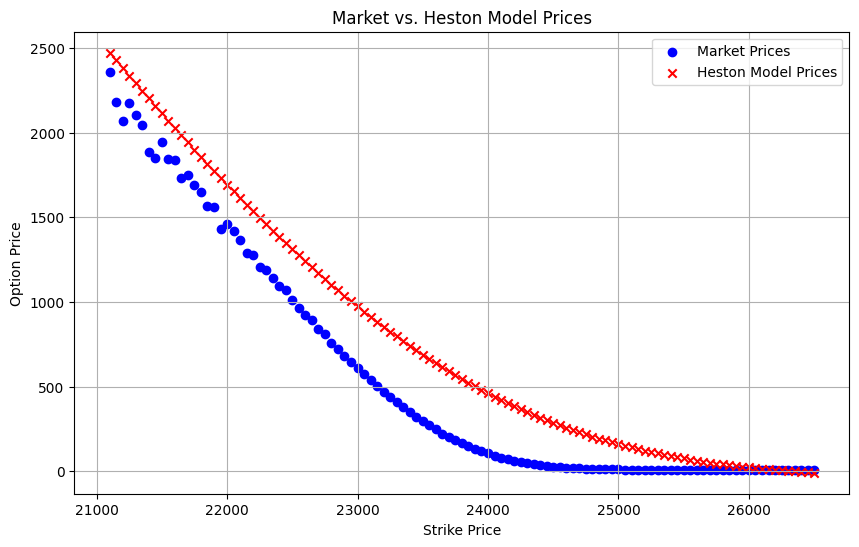

In [71]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(df['strike'], df['price'], label="Market Prices", color='blue', marker='o')
plt.scatter(df['strike'], df['model_price'], label="Heston Model Prices", color='red', marker='x')

plt.xlabel("Strike Price")
plt.ylabel("Option Price")
plt.title("Market vs. Heston Model Prices")
plt.legend()
plt.grid(True)
plt.show()
